# Rendering Cutouts
### To run this notebook, please [follow the instructions](https://lasair-lsst.readthedocs.io/en/main/core_functions/python-notebooks.html) or else it won`t work.
The instructions are at https://lasair-lsst.readthedocs.io/en/main/core_functions/python-notebooks.html

The purpose of this notebook is to show the four different styles of output from the API `object()` call.

In [2]:
import os, sys, time, json
from astropy.io import fits
import astropy.visualization as aviz
import matplotlib.pyplot as plt
from lasair import LasairError, lasair_client as lasair

API_TOKEN = os.getenv('LASAIR_LSST_TOKEN')
if API_TOKEN is None:
    print("No Token found. Check Spelling. Note that if you have just added your token to your environment variables, you may need to restart your terminal so your shell settings are reloaded. ")

In [3]:
endpoint = "https://api.lasair.lsst.ac.uk/api"
L = lasair(API_TOKEN, endpoint=endpoint)

This function summarizes the JSON output. You can use normal `print()` of course
but there may be a large amount of output.

In [4]:
def render_cutouts(ds):
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    types = ['Science', 'Template', 'Difference']

    for i in range(len(types)):
        cutout_type = types[i]
        url = ds[cutout_type]
        hdu = fits.open(url)
        ihdu = 0
        img = hdu[ihdu].data
        ax = axes[i]
        ax.set_title(cutout_type)
        norm = aviz.ImageNormalize(img, interval=aviz.ZScaleInterval())
        s1 = ax.imshow(img, norm=norm, origin="lower")
    plt.show()

#### get a working object with a Sherlock

In [5]:
selected = 'objects.diaObjectId, objects.ra, objects.decl'
tables = 'objects,sherlock_classifications'
conditions = 'nDiaSources > 4 AND classification="SN"'
results = L.query(selected, tables, conditions, limit = 1)
objectId = results[0]['diaObjectId']
print('diaObjectId %s at (ra, dec) = (%.4f, %.4f)' % (objectId, results[0]['ra'], results[0]['decl']))

diaObjectId 170019696262250510 at (ra, dec) = (60.7685, -50.1830)


In [6]:
t = time.time()
result = L.object(objectId, lasair_added=True, lite=True)
print('Time taken = %.3f seconds' % (time.time()-t))

Time taken = 0.262 seconds


diaSourceId=170063670170091536 at MJD 61098.034


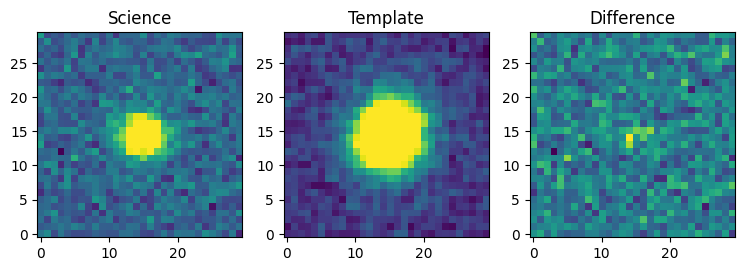

diaSourceId=170063669612773544 at MJD 61098.032


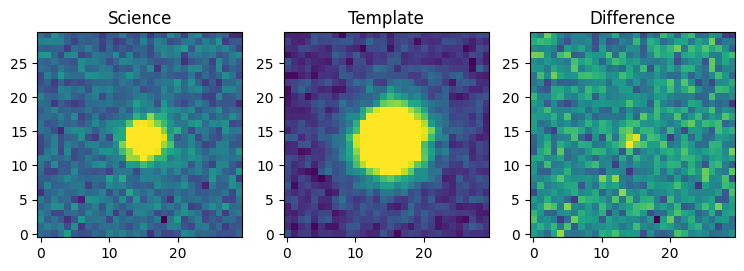

diaSourceId=170063669070135354 at MJD 61098.031


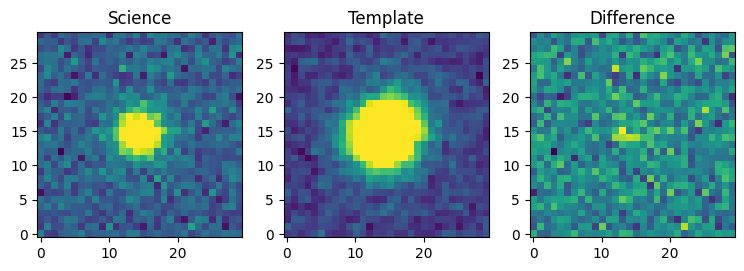

diaSourceId=170063668270071950 at MJD 61098.028


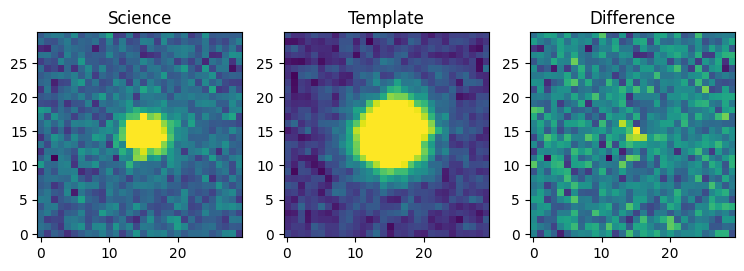

diaSourceId=170054922241310762 at MJD 61096.045


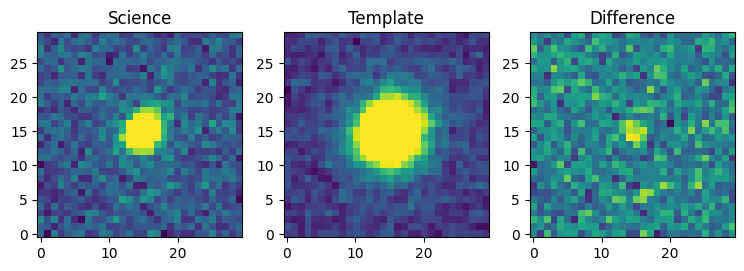

diaSourceId=170054918485835895 at MJD 61096.031


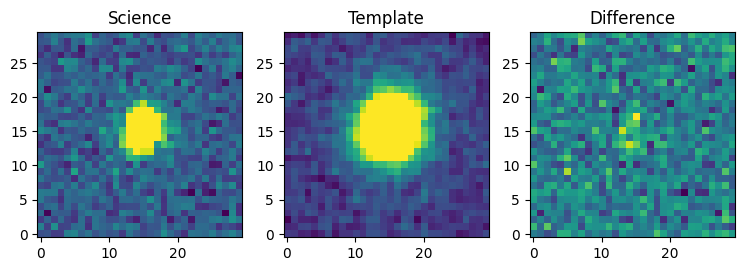

diaSourceId=170050486209609781 at MJD 61095.091


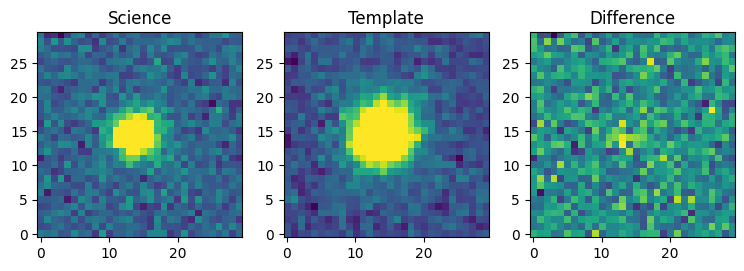

diaSourceId=170050484061601936 at MJD 61095.084


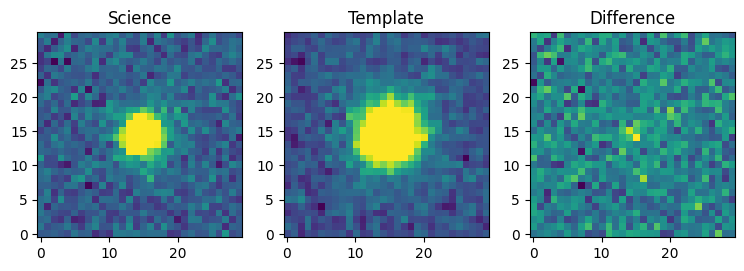

diaSourceId=170050483521061123 at MJD 61095.082


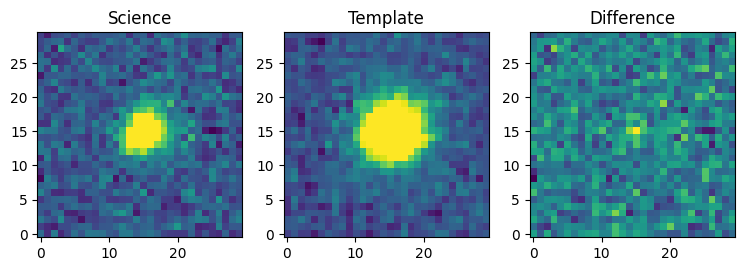

diaSourceId=170050475203231888 at MJD 61095.051


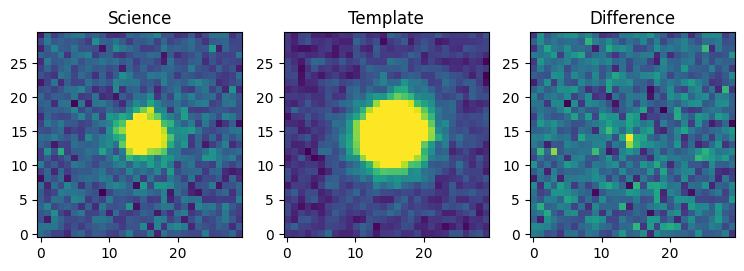

diaSourceId=170050474934796389 at MJD 61095.050


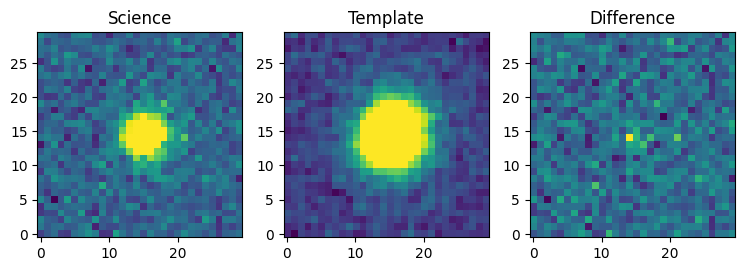

diaSourceId=170050474662166669 at MJD 61095.049


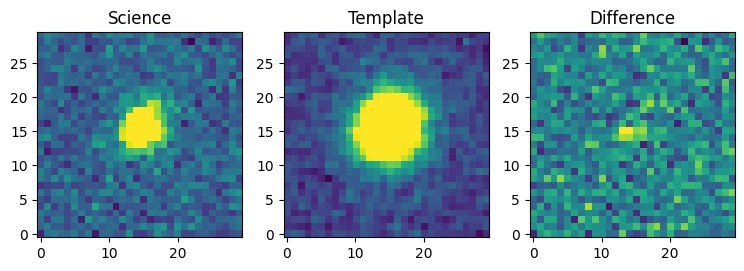

diaSourceId=170050474395304095 at MJD 61095.048


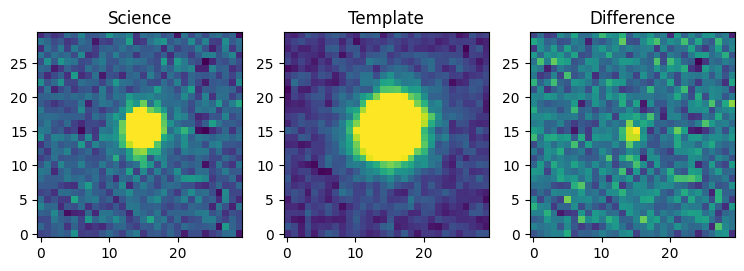

diaSourceId=170050473862627365 at MJD 61095.046


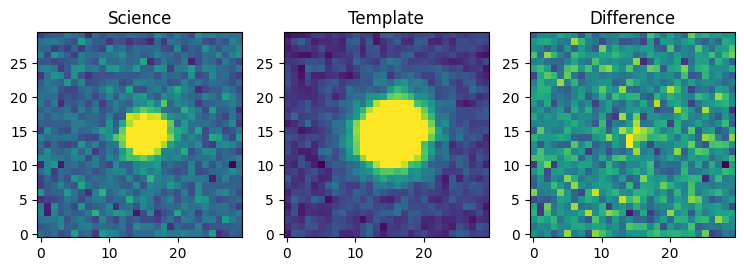

diaSourceId=170050473594191945 at MJD 61095.045


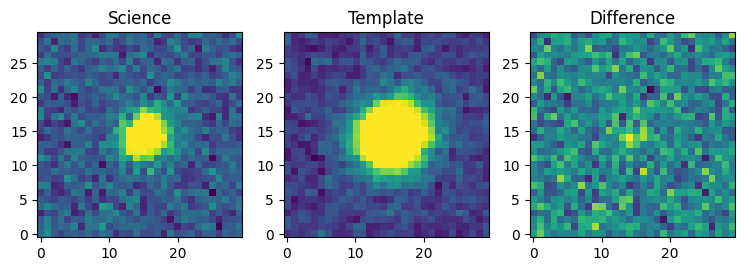

diaSourceId=170046089636348595 at MJD 61094.117


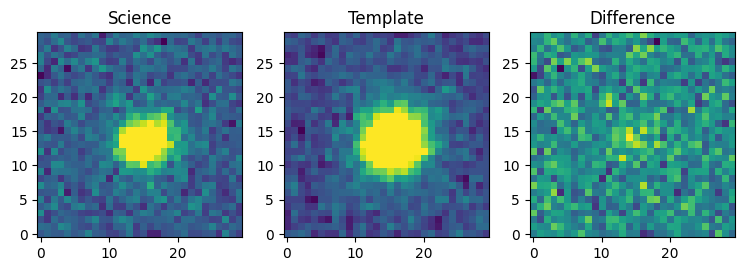

diaSourceId=170032897658978729 at MJD 61091.153


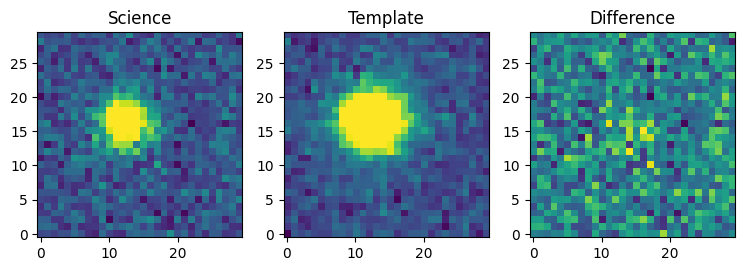

diaSourceId=170032882619252915 at MJD 61091.037


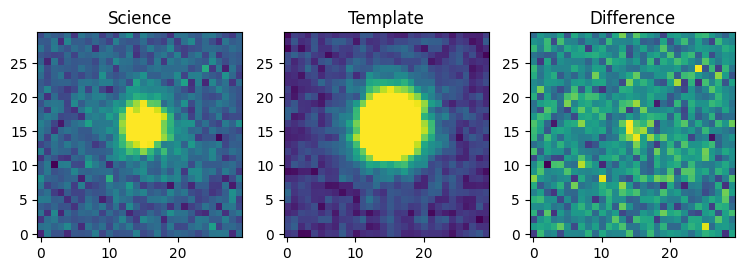

diaSourceId=170032881808703590 at MJD 61091.034


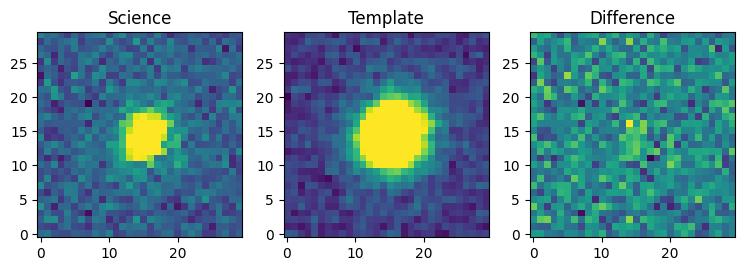

diaSourceId=170032880200712245 at MJD 61091.029


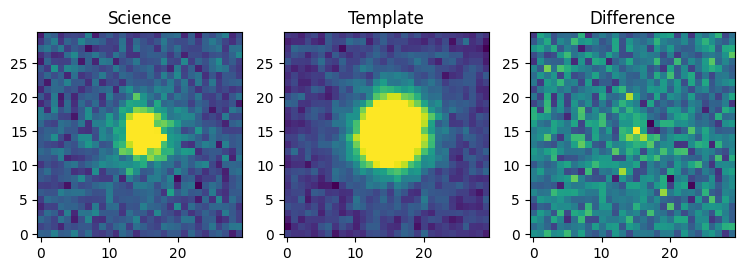

diaSourceId=170028490068328532 at MJD 61090.068


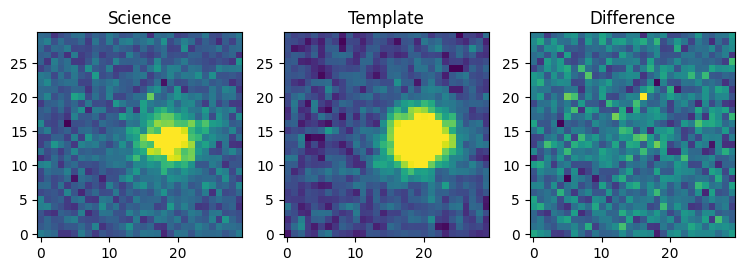

diaSourceId=170019696262250510 at MJD 61088.098


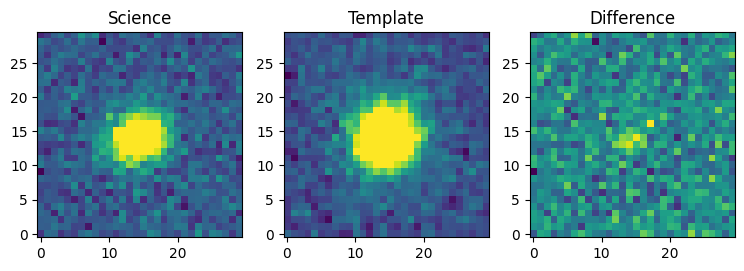

In [7]:
for cutouts_triple,ds in zip(result['lasairData']['imageUrls'], result['diaSourcesList']):
    print('diaSourceId=%d at MJD %.3f' % (cutouts_triple['diaSourceId'], ds['midpointMjdTai']))
    render_cutouts(cutouts_triple)